In [1]:
import os
import ast
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

os.makedirs('AblationStudies', exist_ok=True)
print("Ablation Studies for PCL Classification")

Device: cuda
Ablation Studies for PCL Classification


In [2]:
print("Loading data...")

# Load main data
pcl_df = pd.read_csv(
    'dontpatronizeme_pcl.tsv', sep='\t', skiprows=4,
    names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'orig_label']
)
pcl_df['text'] = pcl_df['text'].fillna('').astype(str)
pcl_df['par_id'] = pcl_df['par_id'].astype(str)

def parse_label(label_str):
    try:
        if isinstance(label_str, str):
            label_list = ast.literal_eval(label_str)
        else:
            label_list = label_str
        return 1 if any(label_list) else 0
    except:
        return 0

# Load train
train_labels_df = pd.read_csv('train.csv')
train_labels_df['binary_label'] = train_labels_df['label'].apply(parse_label)
train_labels_df['par_id'] = train_labels_df['par_id'].astype(str)

# Load dev
dev_labels_df = pd.read_csv('dev.csv')
dev_labels_df['binary_label'] = dev_labels_df['label'].apply(parse_label)
dev_labels_df['par_id'] = dev_labels_df['par_id'].astype(str)

# Merge
train_df = train_labels_df.merge(
    pcl_df[['par_id', 'text', 'keyword']], on='par_id', how='left'
).dropna(subset=['text'])
train_df = train_df[train_df['text'].str.strip().str.len() > 0].reset_index(drop=True)

dev_df = dev_labels_df.merge(
    pcl_df[['par_id', 'text', 'keyword']], on='par_id', how='left'
).dropna(subset=['text'])
dev_df = dev_df[dev_df['text'].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Train: {len(train_df)} (PCL: {(train_df['binary_label']==1).sum()})")
print(f"Dev:   {len(dev_df)} (PCL: {(dev_df['binary_label']==1).sum()})")

Loading data...


Train: 8375 (PCL: 794)
Dev:   2093 (PCL: 199)


In [3]:
class SentenceEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/all-mpnet-base-v2"):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.transformer.config.hidden_size
    
    def mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = self.mean_pooling(outputs, attention_mask)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings
    
    def encode(self, texts, tokenizer, batch_size=32, max_length=128, show_progress=True):
        self.eval()
        all_embeddings = []
        
        iterator = range(0, len(texts), batch_size)
        if show_progress:
            iterator = tqdm(iterator, desc="Encoding")
        
        with torch.no_grad():
            for i in iterator:
                batch_texts = texts[i:i+batch_size]
                encoding = tokenizer(
                    batch_texts, truncation=True, padding=True,
                    max_length=max_length, return_tensors='pt'
                )
                input_ids = encoding['input_ids'].to(device)
                attention_mask = encoding['attention_mask'].to(device)
                embeddings = self.forward(input_ids, attention_mask)
                all_embeddings.append(embeddings.cpu().numpy())
        
        return np.vstack(all_embeddings)


def pcl_indicators(texts):
    patronizing = ['poor', 'unfortunate', 'helpless', 'needy', 'desperate', 'struggling', 'vulnerable']
    savior = ['save', 'rescue', 'help', 'support', 'donate', 'charity', 'give', 'provide']
    
    features = []
    for text in texts:
        text_lower = text.lower()
        words = text_lower.split()
        n = max(len(words), 1)
        
        f = [
            sum(1 for w in patronizing if w in text_lower),
            sum(1 for w in savior if w in text_lower),
            len(text),
            n,
            text.count('!'),
            sum(1 for w in ['we', 'us', 'our'] if w in words),
            sum(1 for w in ['they', 'them', 'their'] if w in words),
        ]
        features.append(f)
    return np.array(features, dtype=np.float32)


def train_and_evaluate(X_train, y_train, X_dev, y_dev, balance_ratio=1.5, threshold=0.38):
    """Train Logistic + RF and evaluate."""
    
    # Balance training data
    pcl_idx = np.where(y_train == 1)[0]
    no_pcl_idx = np.where(y_train == 0)[0]
    n_sample = int(len(pcl_idx) * balance_ratio)
    np.random.seed(42)
    no_pcl_sampled = np.random.choice(no_pcl_idx, size=min(n_sample, len(no_pcl_idx)), replace=False)
    balanced_idx = np.concatenate([pcl_idx, no_pcl_sampled])
    
    X_train_bal = X_train[balanced_idx]
    y_train_bal = y_train[balanced_idx]
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_dev_scaled = scaler.transform(X_dev)
    
    # Train
    clf_log = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
    clf_log.fit(X_train_scaled, y_train_bal)
    
    clf_rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
    clf_rf.fit(X_train_scaled, y_train_bal)
    
    # Ensemble
    probs = (clf_log.predict_proba(X_dev_scaled)[:, 1] + clf_rf.predict_proba(X_dev_scaled)[:, 1]) / 2
    preds = (probs >= threshold).astype(int)
    
    f1 = f1_score(y_dev, preds, pos_label=1)
    precision = precision_score(y_dev, preds, pos_label=1)
    recall = recall_score(y_dev, preds, pos_label=1)
    
    return f1, precision, recall

In [4]:
print("Generating features...")
y_train = train_df['binary_label'].values
y_dev = dev_df['binary_label'].values

# Fine-tuned embeddings (load from saved model)
print("\n1. Loading fine-tuned embeddings...")
model = SentenceEncoder("sentence-transformers/all-mpnet-base-v2")
model.load_state_dict(torch.load('BestModel_dupe/finetuned_encoder.pt', map_location=device))
model = model.to(device)
model.eval()
tokenizer = AutoTokenizer.from_pretrained('BestModel_dupe/tokenizer')

train_emb_finetuned = model.encode(train_df['text'].tolist(), tokenizer)
dev_emb_finetuned = model.encode(dev_df['text'].tolist(), tokenizer)
print(f"  Fine-tuned embeddings: {train_emb_finetuned.shape}")

# Pre-trained embeddings (NOT fine-tuned)
print("\n2. Loading pre-trained embeddings (not fine-tuned)...")
model_pretrained = SentenceEncoder("sentence-transformers/all-mpnet-base-v2")
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

train_emb_pretrained = model_pretrained.encode(train_df['text'].tolist(), tokenizer)
dev_emb_pretrained = model_pretrained.encode(dev_df['text'].tolist(), tokenizer)
print(f"  Pre-trained embeddings: {train_emb_pretrained.shape}")

# TF-IDF features
print("\n3. Generating TF-IDF features...")
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf.fit(train_df['text'].tolist())

train_tfidf = tfidf.transform(train_df['text'].tolist()).toarray()
dev_tfidf = tfidf.transform(dev_df['text'].tolist()).toarray()
print(f"  TF-IDF features: {train_tfidf.shape}")

# PCL indicators
print("\n4. Generating PCL indicators...")
train_pcl = pcl_indicators(train_df['text'].tolist())
dev_pcl = pcl_indicators(dev_df['text'].tolist())
print(f"  PCL indicators: {train_pcl.shape}")

print("\nAll features generated.")

Generating features...

1. Loading fine-tuned embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Encoding:   0%|                                                                                             | 0/262 [00:00<?, ?it/s]


Encoding:   0%|▎                                                                                    | 1/262 [00:00<01:04,  4.03it/s]

...


Encoding:  89%|███████████████████████████████████████████████████████████████████████████▉         | 59/66 [00:02<00:00, 27.62it/s]


Encoding:  95%|█████████████████████████████████████████████████████████████████████████████████▏   | 63/66 [00:02<00:00, 28.35it/s]


Encoding: 100%|█████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:02<00:00, 28.73it/s]

  Pre-trained embeddings: (8375, 768)

3. Generating TF-IDF features...


  TF-IDF features: (8375, 3000)

4. Generating PCL indicators...
  PCL indicators: (8375, 7)

All features generated.


In [5]:
print("Ablation studies - Component removal.")
ablation_results = []

# Full model (all components)
print("\nFull Model (all components)...")
X_train_full = np.hstack([train_emb_finetuned, train_tfidf, train_pcl])
X_dev_full = np.hstack([dev_emb_finetuned, dev_tfidf, dev_pcl])
f1, prec, rec = train_and_evaluate(X_train_full, y_train, X_dev_full, y_dev)
ablation_results.append({
    'Configuration': 'Full Model',
    'Components': 'Fine-tuned Emb + TF-IDF + PCL Indicators',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': X_train_full.shape[1]
})
print(f"  F1: {f1:.4f}")

# Without fine-tuning (using pre-trained embeddings)
print("\nWithout Fine-tuning (pre-trained embeddings)...")
X_train_no_ft = np.hstack([train_emb_pretrained, train_tfidf, train_pcl])
X_dev_no_ft = np.hstack([dev_emb_pretrained, dev_tfidf, dev_pcl])
f1, prec, rec = train_and_evaluate(X_train_no_ft, y_train, X_dev_no_ft, y_dev)
ablation_results.append({
    'Configuration': 'No Fine-tuning',
    'Components': 'Pre-trained Emb + TF-IDF + PCL Indicators',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': X_train_no_ft.shape[1]
})
print(f"  F1: {f1:.4f}")

# Without TF-IDF
print("\nWithout TF-IDF...")
X_train_no_tfidf = np.hstack([train_emb_finetuned, train_pcl])
X_dev_no_tfidf = np.hstack([dev_emb_finetuned, dev_pcl])
f1, prec, rec = train_and_evaluate(X_train_no_tfidf, y_train, X_dev_no_tfidf, y_dev)
ablation_results.append({
    'Configuration': 'No TF-IDF',
    'Components': 'Fine-tuned Emb + PCL Indicators',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': X_train_no_tfidf.shape[1]
})
print(f"  F1: {f1:.4f}")

# Without PCL indicators
print("\nWithout PCL Indicators...")
X_train_no_pcl = np.hstack([train_emb_finetuned, train_tfidf])
X_dev_no_pcl = np.hstack([dev_emb_finetuned, dev_tfidf])
f1, prec, rec = train_and_evaluate(X_train_no_pcl, y_train, X_dev_no_pcl, y_dev)
ablation_results.append({
    'Configuration': 'No PCL Indicators',
    'Components': 'Fine-tuned Emb + TF-IDF',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': X_train_no_pcl.shape[1]
})
print(f"  F1: {f1:.4f}")

# Embeddings only
print("\nEmbeddings Only...")
f1, prec, rec = train_and_evaluate(train_emb_finetuned, y_train, dev_emb_finetuned, y_dev)
ablation_results.append({
    'Configuration': 'Embeddings Only',
    'Components': 'Fine-tuned Emb',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': train_emb_finetuned.shape[1]
})
print(f"  F1: {f1:.4f}")

# TF-IDF only (like baseline but with same classifier)
print("\nTF-IDF Only...")
f1, prec, rec = train_and_evaluate(train_tfidf, y_train, dev_tfidf, y_dev)
ablation_results.append({
    'Configuration': 'TF-IDF Only',
    'Components': 'TF-IDF',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': train_tfidf.shape[1]
})
print(f"  F1: {f1:.4f}")

# PCL indicators only
print("\nPCL Indicators Only...")
f1, prec, rec = train_and_evaluate(train_pcl, y_train, dev_pcl, y_dev)
ablation_results.append({
    'Configuration': 'PCL Indicators Only',
    'Components': 'PCL Indicators',
    'F1': f1, 'Precision': prec, 'Recall': rec,
    'Features': train_pcl.shape[1]
})
print(f"  F1: {f1:.4f}")

# Create results table
ablation_df = pd.DataFrame(ablation_results)
ablation_df['Drop from Full'] = ablation_df['F1'].iloc[0] - ablation_df['F1']

print("\nAblation results")
print(ablation_df.to_string(index=False))

# Save
ablation_df.to_csv('AblationStudies/component_ablation.csv', index=False)

Ablation studies - Component removal.

Full Model (all components)...


  F1: 0.6486

Without Fine-tuning (pre-trained embeddings)...


  F1: 0.3662

Without TF-IDF...


  F1: 0.6507

Without PCL Indicators...


  F1: 0.6453

Embeddings Only...


  F1: 0.6508

TF-IDF Only...


  F1: 0.2941

PCL Indicators Only...


  F1: 0.2274

Ablation results
      Configuration                                Components       F1  Precision   Recall  Features  Drop from Full
         Full Model  Fine-tuned Emb + TF-IDF + PCL Indicators 0.648649   0.634615 0.663317      3775        0.000000
     No Fine-tuning Pre-trained Emb + TF-IDF + PCL Indicators 0.366197   0.238897 0.783920      3775        0.282451
          No TF-IDF           Fine-tuned Emb + PCL Indicators 0.650667   0.693182 0.613065       775       -0.002018
  No PCL Indicators                   Fine-tuned Emb + TF-IDF 0.645320   0.632850 0.658291      3768        0.003328
    Embeddings Only                            Fine-tuned Emb 0.650794   0.687151 0.618090       768       -0.002145
        TF-IDF Only                                    TF-IDF 0.294056   0.185526 0.708543      3000        0.354592
PCL Indicators Only                            PCL Indicators 0.227439   0.133162 0.778894         7        0.421209


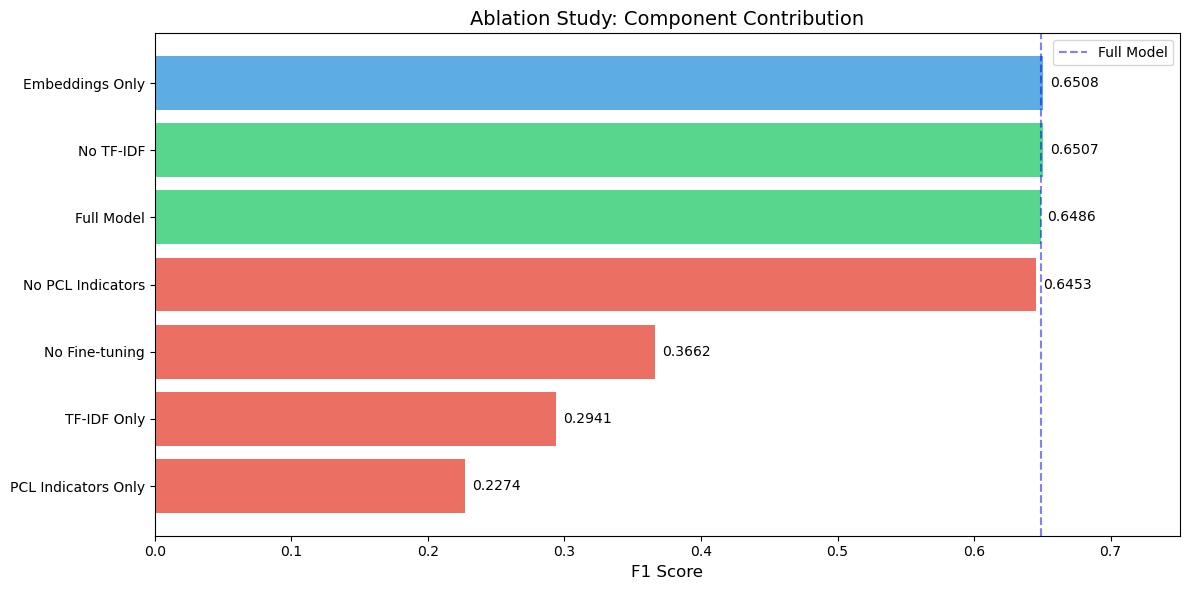


Component Contribution (F1 drop when removed):
      Configuration  Drop from Full
PCL Indicators Only        0.421209
        TF-IDF Only        0.354592
     No Fine-tuning        0.282451
  No PCL Indicators        0.003328
          No TF-IDF       -0.002018
    Embeddings Only       -0.002145


In [6]:
# Visualisation

fig, ax = plt.subplots(figsize=(12, 6))

# Sort by F1
ablation_sorted = ablation_df.sort_values('F1', ascending=True)

colors = ['#e74c3c' if x < ablation_df['F1'].iloc[0] else '#2ecc71' for x in ablation_sorted['F1']]
colors[-1] = '#3498db'  # Full model in blue

bars = ax.barh(ablation_sorted['Configuration'], ablation_sorted['F1'], color=colors, alpha=0.8)

# Add value labels
for bar, f1_val in zip(bars, ablation_sorted['F1']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{f1_val:.4f}', va='center', fontsize=10)

ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Ablation Study: Component Contribution', fontsize=14)
ax.axvline(x=ablation_df['F1'].iloc[0], color='blue', linestyle='--', alpha=0.5, label='Full Model')
ax.legend()
ax.set_xlim(0, max(ablation_df['F1']) + 0.1)

plt.tight_layout()
plt.savefig('AblationStudies/component_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

# Component contribution chart
print("\nComponent Contribution (F1 drop when removed):")
contributions = ablation_df[['Configuration', 'Drop from Full']].iloc[1:].sort_values('Drop from Full', ascending=False)
print(contributions.to_string(index=False))

Ablation: Threshold Sensitivity


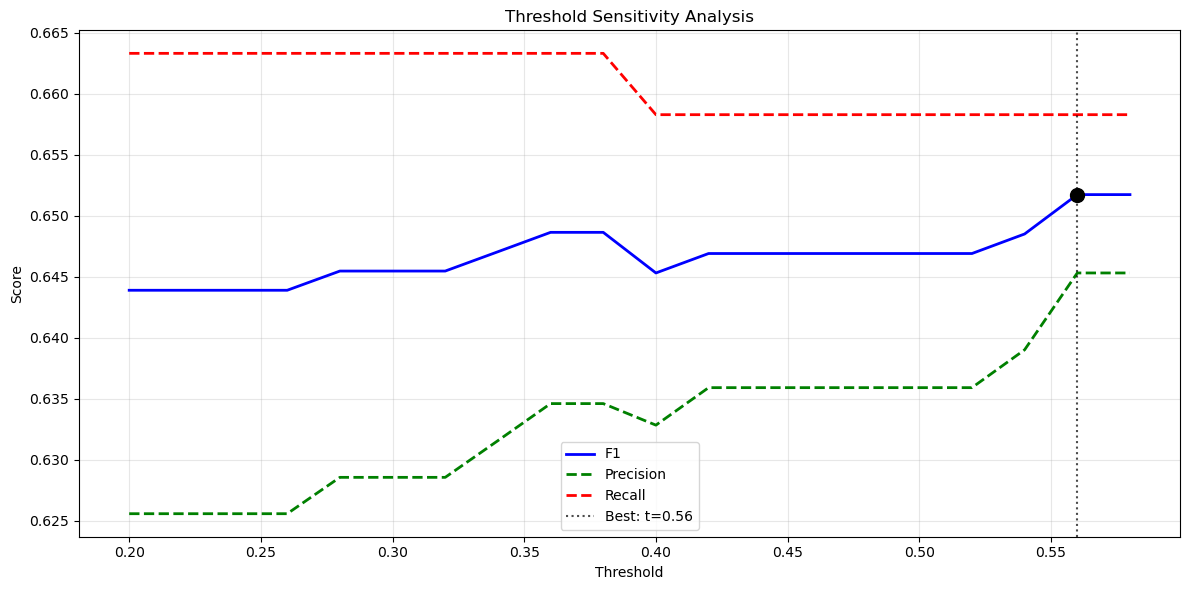

In [7]:
print("Ablation: Threshold Sensitivity")

# Get probabilities
pcl_idx = np.where(y_train == 1)[0]
no_pcl_idx = np.where(y_train == 0)[0]
n_sample = int(len(pcl_idx) * 1.5)
np.random.seed(42)
no_pcl_sampled = np.random.choice(no_pcl_idx, size=min(n_sample, len(no_pcl_idx)), replace=False)
balanced_idx = np.concatenate([pcl_idx, no_pcl_sampled])

X_train_bal = X_train_full[balanced_idx]
y_train_bal = y_train[balanced_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_dev_scaled = scaler.transform(X_dev_full)

clf_log = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
clf_log.fit(X_train_scaled, y_train_bal)
clf_rf.fit(X_train_scaled, y_train_bal)

dev_probs = (clf_log.predict_proba(X_dev_scaled)[:, 1] + clf_rf.predict_proba(X_dev_scaled)[:, 1]) / 2

# Test different thresholds
threshold_results = []
for t in np.arange(0.20, 0.60, 0.02):
    preds = (dev_probs >= t).astype(int)
    f1 = f1_score(y_dev, preds, pos_label=1)
    prec = precision_score(y_dev, preds, pos_label=1, zero_division=0)
    rec = recall_score(y_dev, preds, pos_label=1, zero_division=0)
    n_pcl = preds.sum()
    
    threshold_results.append({
        'Threshold': t,
        'F1': f1,
        'Precision': prec,
        'Recall': rec,
        'PCL Predicted': n_pcl
    })

threshold_df = pd.DataFrame(threshold_results)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['Threshold'], threshold_df['F1'], 'b-', linewidth=2, label='F1')
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 'g--', linewidth=2, label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], 'r--', linewidth=2, label='Recall')

best_idx = threshold_df['F1'].idxmax()
best_thresh = threshold_df.loc[best_idx, 'Threshold']
best_f1 = threshold_df.loc[best_idx, 'F1']

ax.axvline(x=best_thresh, color='black', linestyle=':', alpha=0.7, label=f'Best: t={best_thresh:.2f}')
ax.scatter([best_thresh], [best_f1], color='black', s=100, zorder=5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity Analysis')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AblationStudies/threshold_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

threshold_df.to_csv('AblationStudies/threshold_sensitivity.csv', index=False)

In [8]:
print("="*70)
print("ABLATION STUDY SUMMARY")
print("="*70)

summary = f"""
ABLATION STUDY SUMMARY
======================

1. COMPONENT CONTRIBUTION
   Full Model F1: {ablation_df['F1'].iloc[0]:.4f}
   
   Component Impact (F1 drop when removed):
   - Fine-tuning: {ablation_df[ablation_df['Configuration']=='No Fine-tuning']['Drop from Full'].iloc[0]:.4f}
   - TF-IDF: {ablation_df[ablation_df['Configuration']=='No TF-IDF']['Drop from Full'].iloc[0]:.4f}
   - PCL Indicators: {ablation_df[ablation_df['Configuration']=='No PCL Indicators']['Drop from Full'].iloc[0]:.4f}

2. OPTIMAL THRESHOLD
   {best_thresh:.2f} (F1 = {best_f1:.4f})

"""

print(summary)


print("\nAblation studies completed.")

ABLATION STUDY SUMMARY

ABLATION STUDY SUMMARY

1. COMPONENT CONTRIBUTION
   Full Model F1: 0.6486

   Component Impact (F1 drop when removed):
   - Fine-tuning: 0.2825
   - TF-IDF: -0.0020
   - PCL Indicators: 0.0033

2. OPTIMAL THRESHOLD
   0.56 (F1 = 0.6517)



Ablation studies completed.
